In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm

In [2]:
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
ds = xr.open_dataset('/share/pech2273/EC_Earth_Data.nc')
dsIFS = xr.open_dataset('/share/pech2273/EC_Earth_Data_IFS_34_levels.nc')
ds = ds.chunk(time = 1000)
dsIFS = dsIFS.chunk(time = 1000)
stations = ds["station"].values
TestStation = ['SMR-II']
radii = np.logspace(0, 2.7, 61) #1 to 500 nm RADIUS
VarList = []
IFSVarList = []
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})
#reg_ds = xr.open_dataset('/share/pech2273/EC_Earth_Susceptibility_All_Levels.nc')
#CCN_CDNC_ds = xr.open_dataset('/share/pech2273/EC_Earth_Data_CCN_CDNC.nc')
#dNdlogD = xr.open_dataset('/share/pech2273/EC_Earth_PNSD.nc')
ds = ds.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))
dsIFS = dsIFS.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))
#CCN_CDNC_ds = CCN_CDNC_ds.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))

In [3]:
#Define variables for the ERF
radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
ModesSigma = [1.59, 1.59, 1.59,  1.59, 2.0, 1.59, 2.0]

for radius, number in zip(radius_variables, Numb_variables):
    if radius in ds and number in ds:
            if ds[radius].attrs["units"] == "m" :
                ds[radius] = ds[radius]*1e9
                ds[radius].attrs["units"] = "nm"
                print(f' {radius} changed to nm')
            else:
                continue
            if  ds[number].attrs["units"] == '1 m-3':
                ds[number] = ds[number]/1e6
                ds[number].attrs["units"] = "#cm-3"
                print(f' {number} added to Dataset')
            else: 
                continue
    else:
        print(f'{radius, number} not found in EC Path Data')

 RDRY_NUS changed to nm
 N_NUS added to Dataset
 RDRY_AIS changed to nm
 N_AIS added to Dataset
 RDRY_ACS changed to nm
 N_ACS added to Dataset
 RWET_AII changed to nm
 N_AII added to Dataset
 RDRY_COS changed to nm
 N_COS added to Dataset
 RWET_ACI changed to nm
 N_ACI added to Dataset
 RWET_COI changed to nm
 N_COI added to Dataset


In [4]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out

In [5]:
dsIFS['var22'].max().values*8/10

np.float32(8640.0)

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [6]:
cdnc = (dsIFS["var20"] / dsIFS["var22"]).where(dsIFS["var22"] >= 8640.0)


In [7]:
cdnc = cdnc.rename({"level_tgt": "lev"})


In [8]:
#CCN_CDNC_ds

In [9]:
# NOTE: Deferred .compute() — keep data lazy so Dask can parallelise
# downstream regression work. We only compute when we have a reduced slice.
# CCN_CDNC_ds = CCN_CDNC_ds.compute()  # <-- removed: forces 3 GB to RAM too early


In [10]:
CCN_ds = Function.ECEarthERF(ds, radii)
CCN_ds 

<xarray.DataArray 'CCN' (radius: 61, station: 15, time: 8766, lev: 34)> Size: 2GB
dask.array<concatenate, shape=(61, 15, 8766, 34), dtype=float64, chunksize=(1, 15, 1000, 34), chunktype=numpy.ndarray>
Coordinates:
  * lev        (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * time       (time) datetime64[ns] 70kB 2012-01-01T03:00:00 ... 2015-01-01T...
    time_orig  (time) datetime64[ns] 70kB dask.array<chunksize=(1000,), meta=np.ndarray>
    lev_ifs    float64 8B 3.0
  * radius     (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2

In [11]:
CCN_CDNC_ds = CCN_CDNC_Dataset(CCN_ds, cdnc)

In [12]:
CCN_CDNC_ds = CCN_CDNC_ds.where(cdnc > 0.0)

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [13]:
#CCN_CDNC_ds.to_netcdf('/share/pech2273/EC_Earth_Data_CCN_CDNC.nc')

In [14]:
def binned_loglog_regression(CCN, CDNC):
    """
    CCN, CDNC: 1D arrays (time)
    Bins are computed from min/max of CCN automatically.
    """
    # finite & positive only
    mask = np.isfinite(CCN) & np.isfinite(CDNC) & (CCN > 0) & (CDNC > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    CCN = CCN[mask]
    CDNC = CDNC[mask]

    # Dynamic bins from min to max of this CCN slice
    bins = np.logspace(np.log10(CCN.min()), np.log10(CCN.max()), 101)

    # digitize CCN
    bin_idx = np.digitize(CCN, bins) - 1
    nbins = len(bins) - 1
    CCN_b  = np.full(nbins, np.nan)
    CDNC_b = np.full(nbins, np.nan)
    for i in range(nbins):
        sel = bin_idx == i
        if sel.any():
            CCN_b[i]  = CCN[sel].mean()
            CDNC_b[i] = CDNC[sel].mean()

    # log-log regression
    x = np.log10(CCN_b)
    y = np.log10(CDNC_b)
    good = np.isfinite(x) & np.isfinite(y)
    if good.sum() < 20:
        return np.nan, np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x[good], y[good]
    )
    return slope, r_value, std_err

results = xr.apply_ufunc(
    binned_loglog_regression,
    CCN_CDNC_ds["CCN"],
    CCN_CDNC_ds["CDNC"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float],
    dask_gufunc_kwargs={"allow_rechunk": True},
)

In [15]:
reg_ds_lev = xr.Dataset(
    {
        "slope":   results[0],
        "r_value": results[1],
        "std_err": results[2],  # FIX: was results[0] (slope) — silent data corruption
    }
)


In [23]:
# FIX: xarray DataArrays have no .flatten(); use .stack() to combine time+lev
# into a single core dimension before passing to the regression function.
results = xr.apply_ufunc(
    binned_loglog_regression,
    CCN_CDNC_ds["CCN"].stack(time_lev=("time", "lev")),
    CCN_CDNC_ds["CDNC"].stack(time_lev=("time", "lev")),
    input_core_dims=[["time_lev"], ["time_lev"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float],
    dask_gufunc_kwargs={"allow_rechunk": True},

)
reg_ds = xr.Dataset(
    {
        "slope":   results[0],
        "r_value": results[1],
        "std_err": results[2],  # FIX: was results[0] (slope) — silent data corruption
    }
)

In [18]:
reg_ds_lev = reg_ds_lev.compute()

(100000.0, 20000.0)

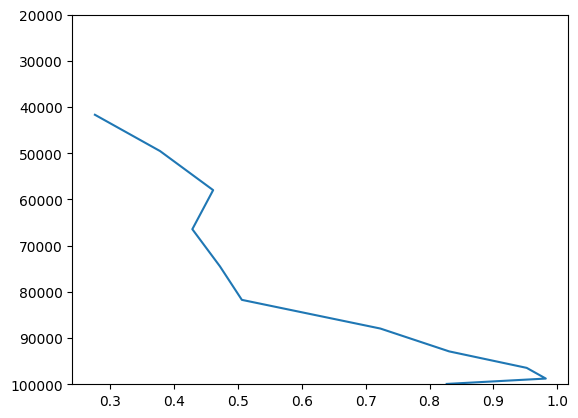

In [19]:
plt.plot(reg_ds_lev.slope.sel(station='SMR-II').isel(radius = 2), ds['pressure'].sel(station = 'SMR-II').mean('time'))
plt.ylim([100000,20000])


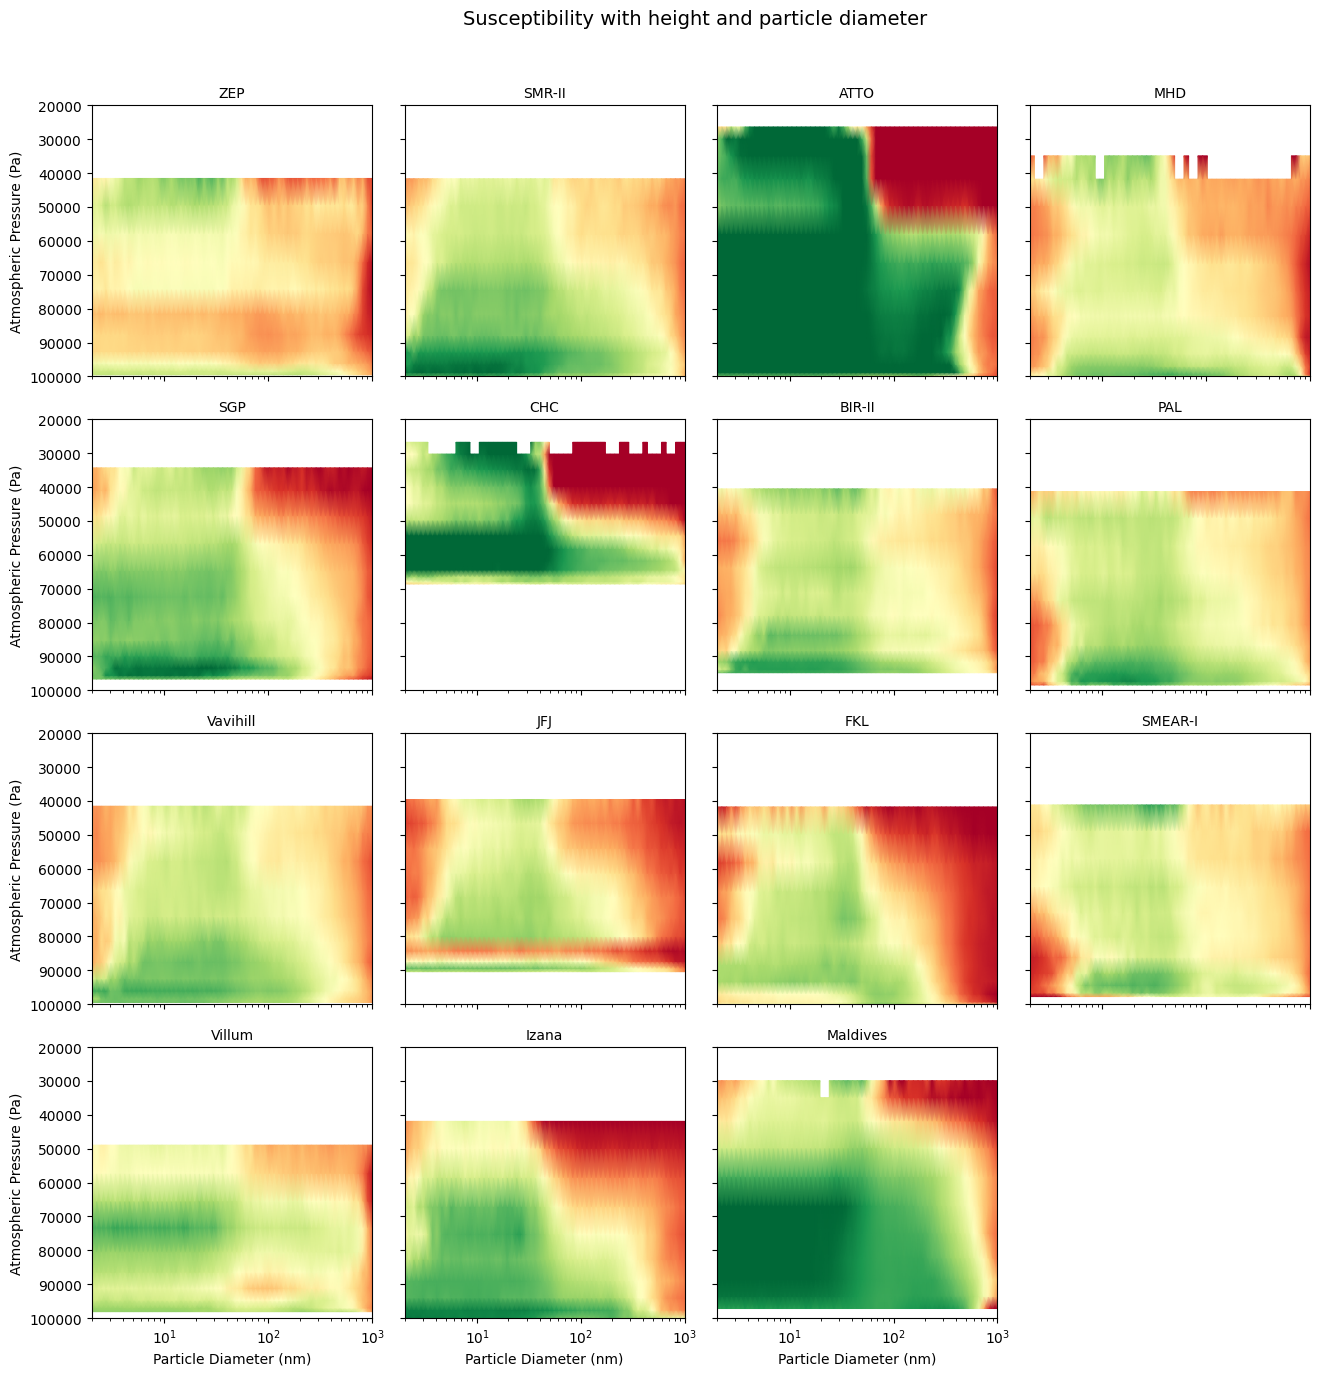

In [20]:
import numpy as np
import matplotlib.pyplot as plt

stations = reg_ds_lev.station.values
n_stations = len(stations)

# --- Create figure and axes ---
fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# --- Loop over stations ---
for i, station in enumerate(stations):
    ax = axes[i]

    mesh = ax.pcolormesh(
        reg_ds_lev['radius'] * 2,
        ds['pressure'].sel(station=station).mean('time'),
        reg_ds_lev.slope.sel(station=station).T,
        shading='gouraud',
        vmin=0,
        vmax=1,
        cmap='RdYlGn'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim(2, 1000)
    ax.set_ylim([100000,20000])

# --- Turn off unused panels ---
for j in range(i + 1, len(axes)):
    axes[j].axis('off')



# --- Axis labels on outer edges only ---
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Atmospheric Pressure (Pa)')

# --- Figure title and layout ---
fig.suptitle(
    'Susceptibility with height and particle diameter',
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()


In [25]:
reg_ds = reg_ds.compute()


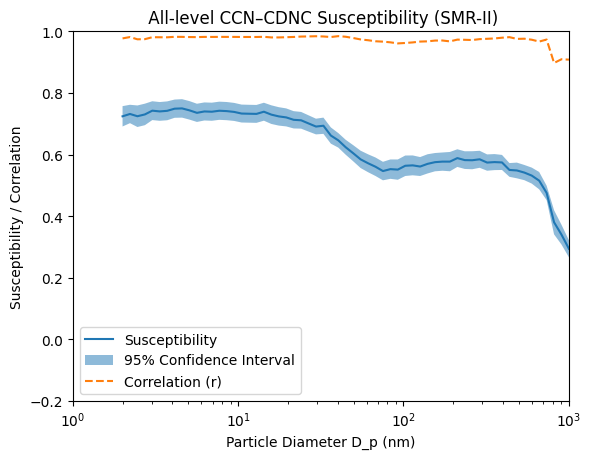

In [24]:
plt.plot(radii*2, reg_ds['slope'].sel(station = 'SMR-II'), label = 'Susceptibility')
plt.fill_between(radii*2,
                 reg_ds['slope'].sel(station = 'SMR-II')-1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 reg_ds['slope'].sel(station = 'SMR-II')+1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds['r_value'].sel(station = 'SMR-II'), '--', label = 'Correlation (r)')
plt.legend()
plt.title(" All-level CCN–CDNC Susceptibility (SMR-II)")
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

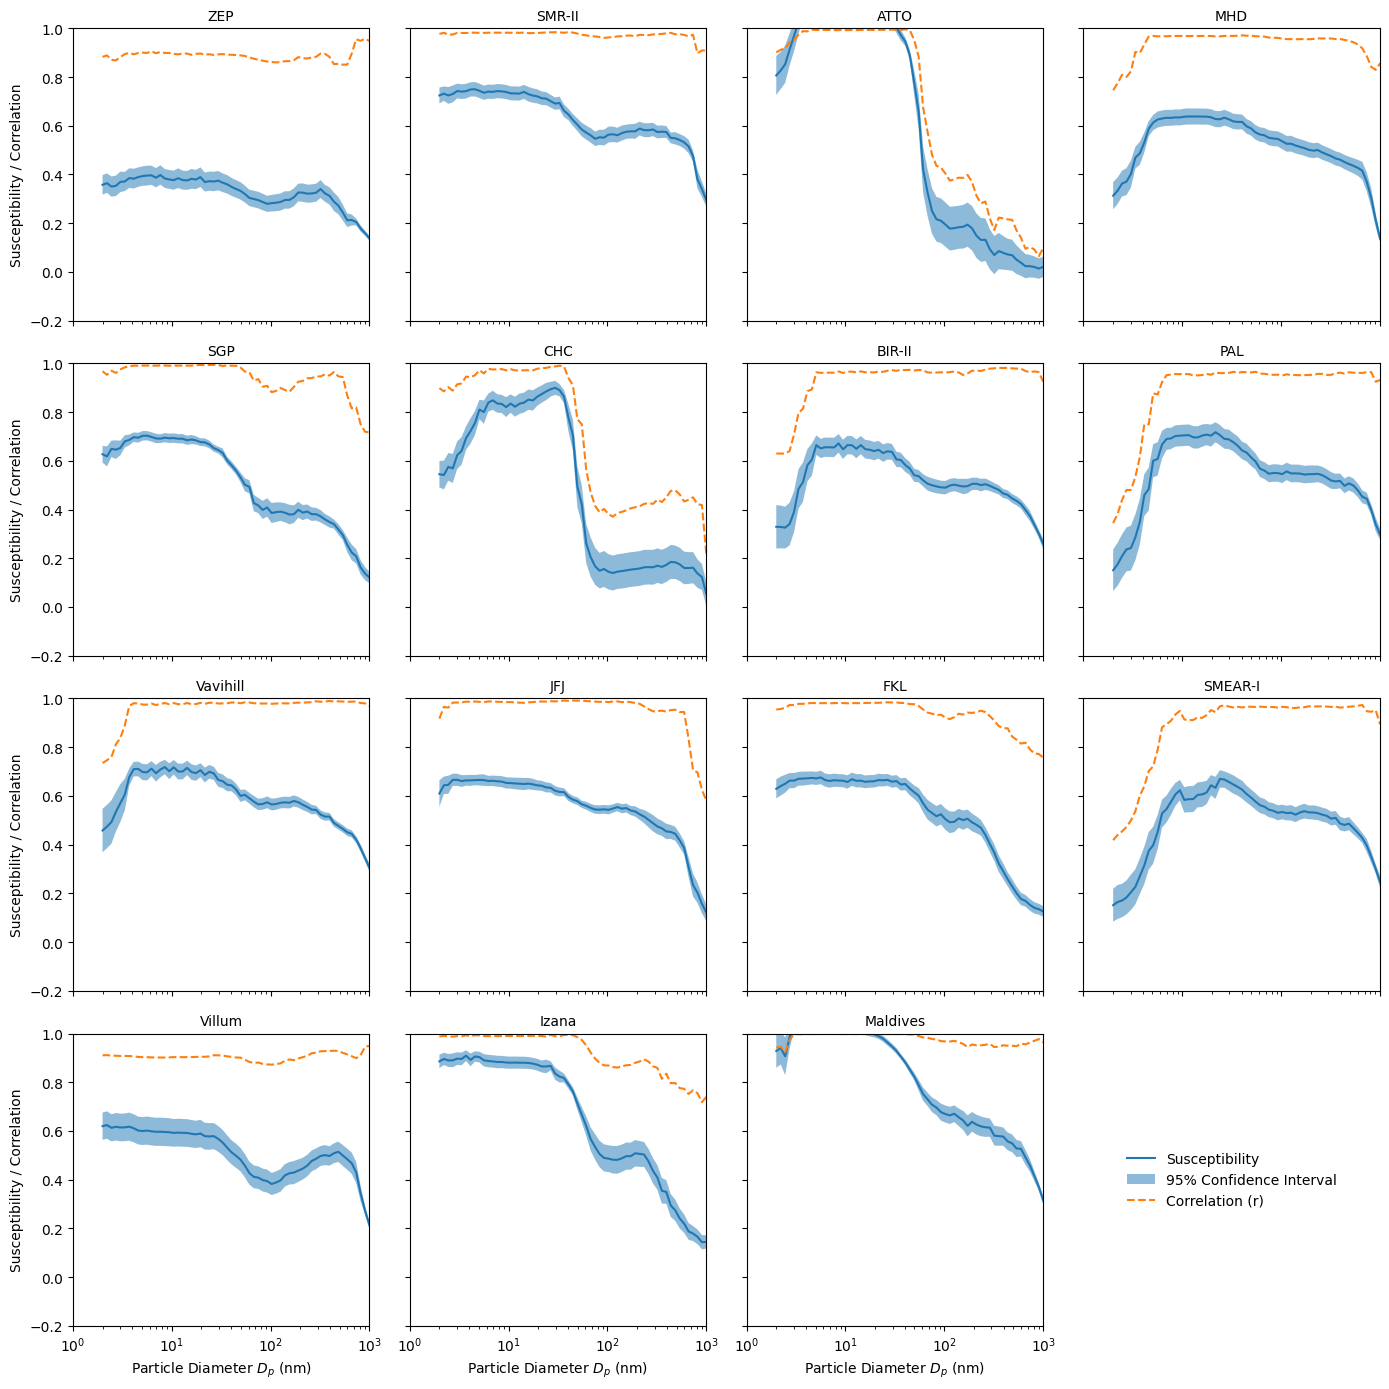

In [26]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(radii * 2, slope, label='Susceptibility')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(
        radii * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()


In [ ]:
plt.scatter(reg_ds['radius']*2,reg_ds['slope'].mean('station'), label = 'Mean')
plt.errorbar(reg_ds['radius']*2,reg_ds['slope'].mean('station'), reg_ds['slope'].std('station'),    fmt='o',
    label='Mean ±1σ'
)
plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title('EC-Earth Susceptibility, All stations')
plt.legend()

In [ ]:
#reg_ds.to_netcdf('/share/pech2273/EC_Earth_Susceptibility_All_Levels.nc')
#reg_ds_lev.to_netcdf('/share/pech2273/EC_Earth_Susceptibility_By_Levels.nc')

In [ ]:
def dNdlogD(N,x,mu,sigma):
    return N*np.exp(-(np.log10(x) - np.log10(mu*2))**2 / (2 * np.log10(sigma)**2))/ (np.log10(sigma) * np.sqrt(2 * np.pi))  


In [ ]:
reg_ds = reg_ds.compute()

In [ ]:
radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
ModesSigma = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]
Xspace = xr.DataArray(np.logspace(-0.5,3, num=50), dims =['R'], coords= {'R':np.logspace(-0.5,3, num=50)})

PNSD_ds = xr.Dataset()
for radius, conc in zip(radius_variables, Numb_variables):
    if radius in ds and conc in ds:
        PNSD_ds[radius] = ds[radius]
        PNSD_ds[conc] = ds[conc]

# Compute distributions lazily with Dask
dis_variable = ["NUS_dis", "AIS_dis", "ACS_dis", "COS_dis", "AII_dis", "ACI_dis", "COI_dis"]

for radius, conc, sigma, dist in zip(radius_variables, Numb_variables, ModesSigma, dis_variable):
    if radius not in PNSD_ds or conc not in PNSD_ds:
        continue

    PNSD_ds[dist] = xr.apply_ufunc(
        dNdlogD,
        PNSD_ds[conc],
        Xspace,
        PNSD_ds[radius] * 2,
        sigma,
        dask="parallelized",
        dask_gufunc_kwargs={'allow_rechunk': True},
        output_dtypes=[float],
    )

# Combine all dNdlogD modes lazily
dNdlogD_vars = [v for v in PNSD_ds.data_vars if v.endswith("_dis")]
if len(dNdlogD_vars) > 0:
    PNSD_ds["dNdlogD"] = sum(PNSD_ds[v] for v in dNdlogD_vars)

In [ ]:
dNdlogD = PNSD_ds["dNdlogD"].compute()

In [ ]:
dNdlogD.to_netcdf('/share/pech2273/EC_Earth_PNSD.nc')

In [ ]:
dNdlogD

In [ ]:
fig, ax1 = plt.subplots()

# ---- Left y-axis: susceptibility & correlation ----
ax1.plot(
    radii * 2,
    reg_ds['slope'].sel(station='SMR-II'),
    label='Susceptibility'
)

ax1.fill_between(
    radii * 2,
    reg_ds['slope'].sel(station='SMR-II')
    - 1.98 * reg_ds['std_err'].sel(station='SMR-II'),
    reg_ds['slope'].sel(station='SMR-II')
    + 1.98 * reg_ds['std_err'].sel(station='SMR-II'),
    alpha=0.5,
    label='95% Confidence Interval'
)

ax1.plot(
    radii * 2,
    reg_ds['r_value'].sel(station='SMR-II'),
    '--',
    label='Correlation (r)'
)

ax1.set_xlabel('Particle Diameter Dₚ (nm)')
ax1.set_ylabel('Susceptibility / Correlation')
ax1.set_ylim([-0.2, 1])
ax1.set_xscale('log')
ax1.set_xlim([1, 1000])

# ---- Right y-axis: PNSD_ds ----
ax2 = ax1.twinx()

ax2.plot(
    dNdlogD['R'] * 2,
    dNdlogD.sel(station='SMR-II').isel(lev = slice(0,7,1)).mean('lev').mean('time'),
    color='black',
    label='dN/dlogD'
)
ax2.fill_between(
    dNdlogD['R'] * 2,
    dNdlogD.sel(station='SMR-II').isel(lev = slice(1,7,1)).mean('lev').quantile(.25, dim = 'time'),
    dNdlogD.sel(station='SMR-II').isel(lev = slice(1,7,1)).mean('lev').quantile(.75, dim = 'time'),
    label = 'dN/dlogD IQR',
    color = 'black',
    alpha = 0.2
)

ax2.set_ylabel('dN / dlogD (# cm-3)')
ax2.set_yscale('log')
ax2.set_ylim([.1, 5000])


# ---- Title ----
plt.title(
    f'CCN–CDNC Susceptibility (SMR-II)'
)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(.9, 0.4)
)
plt.show()

In [ ]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

ax2_first = None  # store first twin axis for legend

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    # ---- Left axis: susceptibility & correlation ----
    ax.plot(
        radii * 2,
        slope,
        label='Susceptibility'
    )

    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )

    ax.plot(
        radii * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

    # ---- Right axis: PNSD ----
    ax2 = ax.twinx()

    pnsd = (
        dNdlogD
        .sel(station=station)
        .isel(lev=slice(1, 7, 1))
        .mean('lev')
    )

    ax2.plot(
        dNdlogD['R'] * 2,
        pnsd.mean('time'),
        color='black',
        alpha=0.6,
        label='PNSD'
    )

    ax2.fill_between(
        dNdlogD['R'] * 2,
        pnsd.quantile(0.25, dim='time'),
        pnsd.quantile(0.75, dim='time'),
        color='black',
        alpha=0.2,
        label='dN/dlogD IQR'
    )

    ax2.set_yscale('log')
    ax2.set_ylim([.1, 7000])
    ax2.tick_params(axis='y', labelsize=8)
    ax2.set_ylabel('')

    # store first twin axis for legend
    if ax2_first is None:
        ax2_first = ax2

# ---- Last panel used only for legend ----
legend_ax = axes[-1]
legend_ax.axis('off')

# ---- Combined legend (NO new twinx call) ----
handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = ax2_first.get_legend_handles_labels()

legend_ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='center',
    frameon=False,
    fontsize=10
)

# ---- Axis labels (only on outer edges) ----
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

# ---- Single right-axis label ----
fig.text(0.92, 0.5, 'dN / dlogD', va='center', rotation=-90)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [ ]:
mask = CCN_CDNC_ds.where(CCN_CDNC_ds['CDNC']>0)
CCN_all_Summed = mask.sum('lev')

In [ ]:
CCN_all_Summed

In [ ]:
bins_for_summed = np.logspace(0, 4, 100)
agg_methods = ["mean", "median", "max", "min"]

def regression_binned(ccn, cdnc, bins, agg):
    """1D numpy arrays (time,) → (slope, r_value, std_err, intercept)"""
    finite = np.isfinite(ccn) & np.isfinite(cdnc) & (cdnc > 0)
    if finite.sum() < 2:
        return np.nan, np.nan, np.nan, np.nan

    ccn, cdnc = ccn[finite], cdnc[finite]
    bin_idx = np.digitize(ccn, bins) - 1
    nbins   = len(bins) - 1

    agg_fn = {"mean": np.nanmean, "median": np.nanmedian,
              "max":  np.nanmax,  "min":    np.nanmin}[agg]

    ccn_b  = np.array([agg_fn(ccn[bin_idx == i])  if (bin_idx == i).any() else np.nan
                       for i in range(nbins)])
    cdnc_b = np.array([agg_fn(cdnc[bin_idx == i]) if (bin_idx == i).any() else np.nan
                       for i in range(nbins)])

    x, y = np.log10(ccn_b), np.log10(cdnc_b)
    good = np.isfinite(x) & np.isfinite(y)
    if good.sum() < 2:
        return np.nan, np.nan, np.nan, np.nan

    sl, ic, rv, _, se = stats.linregress(x[good], y[good])
    return sl, rv, se, ic


# CDNC has no radius dim — broadcast it to match CCN's (radius, time) shape
CDNC_broadcast = (
    CCN_all_Summed["CDNC"]
    .expand_dims({"radius": CCN_all_Summed["CCN"].radius})
    .chunk({"time": -1})
)
CCN_chunked = CCN_all_Summed["CCN"].chunk({"time": -1})

reg_results = {}
for agg in agg_methods:
    slope, r_value, std_err, intercept = xr.apply_ufunc(
        regression_binned,
        CCN_chunked,
        CDNC_broadcast,
        kwargs={"bins": bins_for_summed, "agg": agg},
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float, float, float],
    )
    reg_results[agg] = xr.Dataset({
        "slope":     slope,
        "r_value":   r_value,
        "std_err":   std_err,
        "intercept": intercept,
    })
    print(f"  Built graph: {agg}")

# Compute all 4 agg methods in one Dask pass

print("All aggregations complete.")

In [ ]:
reg_ds_summed = reg_results["mean"].compute()
reg_ds_median = reg_results["median"].compute()
reg_ds_max    = reg_results["max"].compute()
reg_ds_min    = reg_results["min"].compute()

In [ ]:
stations = reg_ds_summed.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds_summed['slope'].sel(station=station)
    slope2 = reg_ds['slope'].sel(station=station)
    std_err = reg_ds_summed['std_err'].sel(station=station)
    std_err2 = reg_ds['std_err'].sel(station=station)
    #r_val = reg_ds_summed['r_value'].sel(station=station)

    ax.plot(radii * 2, slope, label='Susceptibility (Column)')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(radii * 2, slope2, label='Susceptibility (all Level)')
    ax.fill_between(
        radii * 2,
        slope2 - 1.96 * std_err2,
        slope2 + 1.96 * std_err2,
        alpha=0.5,
        label='95% Confidence Interval'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [ ]:
plt.scatter(reg_ds['radius']*2,reg_ds['slope'].mean('station'), label = 'Mean (All Levels)')
plt.errorbar(reg_ds['radius']*2,reg_ds['slope'].mean('station'), reg_ds['slope'].std('station'),    fmt='o',
    label='Mean ±1σ', capsize=4
)
plt.scatter(reg_ds_summed['radius']*2,reg_ds_summed['slope'].mean('station'), label = 'Mean (Column)')
plt.errorbar(reg_ds_summed['radius']*2,reg_ds_summed['slope'].mean('station'), reg_ds_summed['slope'].std('station'),    fmt='o',
    label='Mean ±1σ', capsize=4
)
plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title('EC-Earth Susceptibility, All stations')
plt.legend()

In [ ]:
CCN_all_Summed = CCN_all_Summed.compute()
for station in reg_ds_summed.station:
    r = reg_ds_summed['r_value'].sel(station = station).argmax().values
    Log_bins = np.linspace(0,5,201)
    log_x = np.log10(CCN_all_Summed['CCN'].sel(station=station).isel(radius=r).where(CCN_all_Summed['CDNC'].sel(station = station)>0, drop = True))
    log_y = np.log10(CCN_all_Summed['CDNC'].sel(station=station).where(CCN_all_Summed['CDNC'].sel(station = station)>0, drop = True))
    # Binned means
    x_mean = log_x \
        .groupby_bins(log_x, Log_bins).mean()
    
    y_mean = log_y \
        .groupby_bins(log_x, Log_bins).mean()
    
    # Binned standard deviations (errors)
    x_err = log_x \
        .groupby_bins(log_x, Log_bins).std()
    
    y_err = log_y \
        .groupby_bins(log_x, Log_bins).std()
    # Raw data
    plt.scatter(
        x_mean,
        y_mean,
        alpha=0.3,
        label='Binned Mean',
    )

    # Binned means with error bars
    plt.errorbar(
        x_mean,
        y_mean,
        xerr=x_err,
        yerr=y_err,
        fmt='o',
        capsize=3,
        elinewidth=1,
        label='Binned mean ±1σ',
                alpha=0.3,

    )
    plt.hexbin(np.log10(CCN_all_Summed['CCN'].sel(station=station).isel(radius=r).where(CCN_all_Summed['CDNC'].sel(station = station)>0, drop = True)),
                np.log10(CCN_all_Summed['CDNC'].sel(station=station).where(CCN_all_Summed['CDNC'].sel(station = station)>0, drop = True)),
                #c = 'orange',
                #alpha = 0.2
              bins = 'log',
               gridsize = [40,40]
                
              )
    # Reference & formatting
    plt.title(f'Station = {station.values}\n Diameter = {reg_ds_summed['radius'].isel(radius = reg_ds_summed['r_value'].sel(station = station).argmax().values).values*2:.2f} nm \n n = {len(CCN_all_Summed['CCN'].sel(station=station).isel(radius=r).where(CCN_all_Summed['CDNC'].sel(station = station)>0, drop = True))}')
    plt.xlim([0, 4])
    plt.ylim([0, 4])
    plt.plot([0, 4], [0, 4], 'k--')
    
    plt.xlabel('log10(CCN)')
    plt.ylabel('log10(CDNC)')
    plt.legend()
    plt.show()


In [ ]:
# REPLACED: reg_ds_median loop moved into unified agg_methods loop above (cell 36).
# reg_ds_median is now available as reg_results['median'] or reg_ds_median directly.


In [ ]:
# REPLACED: reg_ds_max loop moved into unified agg_methods loop above (cell 36).
# reg_ds_max is now available as reg_results['max'] or reg_ds_max directly.


In [ ]:
# REPLACED: reg_ds_min loop moved into unified agg_methods loop above (cell 36).
# reg_ds_min is now available as reg_results['min'] or reg_ds_min directly.


In [ ]:

plt.plot(reg_ds_min['radius']*2,reg_ds_summed['slope'].mean('station'), label = 'Bin Mean')
plt.fill_between(reg_ds_summed['radius']*2, 
                 reg_ds_summed['slope'].mean('station') - reg_ds_summed['slope'].std('station'),
                 reg_ds_summed['slope'].mean('station') + reg_ds_summed['slope'].std('station'),
                 label='±1σ', 
                 alpha = 0.2
)
plt.plot(reg_ds_median['radius']*2,reg_ds_median['slope'].mean('station'), label = 'Bin Median')
plt.fill_between(reg_ds_median['radius']*2, 
                 reg_ds_median['slope'].mean('station') - reg_ds_median['slope'].std('station'),
                 reg_ds_median['slope'].mean('station') + reg_ds_median['slope'].std('station'),
                 label='±1σ', 
                 alpha = 0.2
)
plt.plot(reg_ds_max['radius']*2,reg_ds_max['slope'].mean('station'), label = 'Bin Max')
plt.fill_between(reg_ds_max['radius']*2, 
                 reg_ds_max['slope'].mean('station') - reg_ds_max['slope'].std('station'),
                 reg_ds_max['slope'].mean('station') + reg_ds_max['slope'].std('station'),
                 label='±1σ', 
                 alpha = 0.2
)
plt.plot(reg_ds_min['radius']*2,reg_ds_min['slope'].mean('station'), label = 'Bin Min')
plt.fill_between(reg_ds_min['radius']*2, 
                 reg_ds_min['slope'].mean('station') - reg_ds_min['slope'].std('station'),
                 reg_ds_min['slope'].mean('station') + reg_ds_min['slope'].std('station'),
                 label='±1σ', 
                 alpha = 0.2
)
plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title('EC-Earth Susceptibility, All stations')
plt.legend()

In [ ]:
stations = reg_ds.station.values

slope = reg_ds_lev['slope'].sel(radius = 35, method='nearest')
plt.scatter(slope, ds['pressure'].mean('time'))
    
plt.title('EC-Earth Susceptibiltiy with Atmospheric Pressure', fontsize=10)
plt.xlim([0,1])
plt.ylim([100000, 7500])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Susceptiblity')

for ax in axes[::4]:
    ax.set_ylabel('Altitude (m)')

plt.tight_layout()
plt.show()

In [ ]:
stations = reg_ds.station.values

slope = reg_ds_lev['slope'].sel(station = 'SMR-II').sel(radius = 35, method='nearest')
std_err = reg_ds_lev['std_err'].sel(station = 'SMR-II').sel(radius = 35, method='nearest')
plt.plot(slope, ds.pressure.sel(station = 'SMR-II').mean('time')/100)

plt.title('EC-Earth: SMR-II Susceptibiltiy with Height', fontsize=10)
plt.xlim([0,1])
plt.ylim([1000, 300])
plt.yscale('log')
plt.xlabel('Susceptibiltiy')
plt.ylabel('Pressure (hPa)')

plt.tight_layout()
plt.show()

In [ ]:
reg_ds_lev.sel(station = 'SMR-II')

In [ ]:
mesh = plt.pcolormesh(
    dNdlogD['R'] * 2,
    ds['pressure'].sel(station='SGP').mean('time'),
    dNdlogD.sel(station='SGP').mean('time'),
    shading='nearest',
    cmap='viridis',
    vmin = 0,
    vmax = 1500
)

plt.xscale('log')
plt.xlim([3, 400])
plt.xticks([3, 10, 50, 100, 200], ['3', '10', '50', '100', '200'])
plt.ylim([100000,80000])
plt.colorbar(mesh, label='dN/dlogD')
plt.xlabel('Diameter (nm)')
plt.ylabel('Pressure (Pa)')
plt.title('Aerosol Size Distribution Year round (SGP)')
plt.tight_layout()

In [ ]:
dNdlogD.sel(station='SGP').isel(lev = 0).mean('time').plot()

In [ ]:
AitAcc_ds = Function.ECEarthERF(ds,[20,100])
N100 = AitAcc_ds.sel(radius = 100) 
N20 = AitAcc_ds.sel(radius = 20) -AitAcc_ds.sel(radius = 100) 
AitAccRatio = N20/N100

In [ ]:
inertias = []
from sklearn.cluster import KMeans

for i in range(1,15):
    kmeans = KMeans(n_clusters=i, random_state = 2, init= 'k-means++')
    kmeans.fit(AitAccRatio.isel(lev = -1).dropna('time'))
    inertias.append(kmeans.inertia_)

plt.plot(range(1,15), inertias, marker='o')
plt.title('EC-Earth Aiken:Accumulation - K-means Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state = 2, init= 'k-means++')
kmeans.fit(AitAccRatio.isel(lev = -1).dropna('time'))
KmeansAitAcc= AitAccRatio.isel(lev = -1).dropna('time').to_dataset()
KmeansAitAcc['label'] = xr.DataArray(kmeans.labels_, dims=('station'))

In [ ]:
AitAccGroup1 = KmeansAitAcc.station.where(KmeansAitAcc.label == 0)
AitAccGroup2 = KmeansAitAcc.station.where(KmeansAitAcc.label == 1)
AitAccGroup3 = KmeansAitAcc.station.where(KmeansAitAcc.label == 2)
AitAccGroup4 = KmeansAitAcc.station.where(KmeansAitAcc.label == 3)
AitAccGroups = [AitAccGroup1,AitAccGroup2,AitAccGroup3,AitAccGroup4]
print(f'Group 1: {AitAccGroup1.dropna('station').values}')
print(f'Group 2: {AitAccGroup2.dropna('station').values}')
print(f'Group 3: {AitAccGroup3.dropna('station').values}')
print(f'Group 4: {AitAccGroup4.dropna('station').values}')


In [ ]:
import pwlf
crit_D = []
crit_D_summed= []

for station in reg_ds.station.values:

    y = reg_ds.slope.sel(station=station).dropna(dim='radius')
    y2 = reg_ds_summed.slope.sel(station=station).dropna(dim='radius')
    radius = reg_ds.radius*2



    mask = y.notnull()
    mask2 = y2.notnull()
    x = np.log10(radius.where(mask))
    x2 = np.log10(radius.where(mask2))
    
    # Convert to numpy arrays
    x = x.values
    x2 = x2.values

    y = y.values
    y2 = y2.values
    #y = savgol_filter(y, 9, 2)

    # Skip if insufficient data
    if len(x) < 10:
        print(station, "Not enough data")
        continue

    # Fit piecewise linear model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    my_pwlf2 = pwlf.PiecewiseLinFit(x2, y2)
    breaks2 = my_pwlf2.fit(2)

    knee_log = breaks[1]
    knee_log2 = breaks2[1]

    Crit_D = 10**knee_log
    Crit_D2 = 10**knee_log2 
    crit_D.append(Crit_D)
    crit_D_summed.append(Crit_D2)
    print(station)
    print('All:', Crit_D)
    print('Summed:', Crit_D2)

In [ ]:
valid_levs = CCN_CDNC_ds['CDNC'].notnull().any(dim=['station', 'time'])
CCN_CDNC_ds = CCN_CDNC_ds.sel(lev=valid_levs)

In [ ]:
import piecewise_regression

Log_bins   = np.linspace(0, 4, 101)
n_radii    = len(CCN_CDNC_ds['radius'])
params     = ['const', 'beta1', 'beta2', 'alpha1', 'alpha2', 'alpha3',
              'breakpoint1', 'breakpoint2']
stat_keys  = ['estimate', 'se', 'ci_lower', 'ci_upper']


def fit_piecewise_1d(ccn, cdnc, log_bin_edges):
    """
    ccn, cdnc: 1D numpy arrays (sample,) for one (station, radius) pair.
    Returns a flat numpy array of all outputs, NaN-filled on failure.
    Output order: [p0_est, p0_se, p0_cil, p0_ciu, p1_est, ...  bic, rss, davies, converged]
    """
    n_params  = len(params)
    n_outputs = n_params * 4 + 4          # 4 stats per param + bic/rss/davies/converged
    out       = np.full(n_outputs, np.nan)

    nbins = len(log_bin_edges) - 1
    with np.errstate(divide='ignore', invalid='ignore'):
        lx = np.log10(ccn)
        ly = np.log10(cdnc)

    valid = np.isfinite(lx) & np.isfinite(ly)
    if valid.sum() < 6:
        return out

    lx, ly  = lx[valid], ly[valid]
    bin_idx = np.digitize(lx, log_bin_edges) - 1
    x_mean  = np.array([lx[bin_idx==i].mean() if (bin_idx==i).any() else np.nan
                        for i in range(nbins)])
    y_mean  = np.array([ly[bin_idx==i].mean() if (bin_idx==i).any() else np.nan
                        for i in range(nbins)])

    good = np.isfinite(x_mean) & np.isfinite(y_mean)
    xc, yc = x_mean[good], y_mean[good]
    if len(xc) < 6:
        return out

    try:
        pw_fit    = piecewise_regression.Fit(xc, yc, n_breakpoints=2)
        pw_result = pw_fit.get_results()
    except Exception:
        return out

    if not pw_result['converged']:
        return out

    estimates = pw_result['estimates']
    for i, p in enumerate(params):
        est = estimates.get(p)
        if est is None:
            continue
        base = i * 4
        out[base]     = est['estimate']
        out[base + 1] = est['se']
        out[base + 2] = est['confidence_interval'][0]
        out[base + 3] = est['confidence_interval'][1]

    base = n_params * 4
    out[base]     = pw_result['bic']
    out[base + 1] = pw_result['rss']
    out[base + 2] = pw_result['davies']
    out[base + 3] = float(pw_result['converged'])

    return out                            # shape: (n_outputs,)


n_outputs = len(params) * 4 + 4

# Flatten time×lev into a single 'sample' core dimension
CCN_stacked  = CCN_CDNC_ds['CCN'].stack(sample=('time', 'lev')).chunk({'sample': -1})
CDNC_stacked = CCN_CDNC_ds['CDNC'].stack(sample=('time', 'lev')).chunk({'sample': -1})

# Broadcast CDNC over radius so shapes align for apply_ufunc
CDNC_broadcast = CDNC_stacked.expand_dims({'radius': CCN_stacked.radius})

raw = xr.apply_ufunc(
    fit_piecewise_1d,
    CCN_stacked,
    CDNC_broadcast,
    kwargs={'log_bin_edges': Log_bins},
    input_core_dims=[['sample'], ['sample']],
    output_core_dims=[['output']],        # function returns 1D array of all outputs
    output_sizes={'output': n_outputs},
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
).compute()

# raw has dims (radius, station, output) — split into named variables
pw_ds = xr.Dataset()
for i, p in enumerate(params):
    base = i * 4
    for j, s in enumerate(stat_keys):
        pw_ds[f'{p}_{s}'] = raw.isel(output=base + j)

base = len(params) * 4
pw_ds['bic']       = raw.isel(output=base)
pw_ds['rss']       = raw.isel(output=base + 1)
pw_ds['davies']    = raw.isel(output=base + 2)
pw_ds['converged'] = raw.isel(output=base + 3).astype(bool)

In [ ]:
pw_ds

In [ ]:
stations = pw_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = pw_ds['alpha1_estimate'].sel(station=station)
    slope2 = pw_ds['alpha2_estimate'].sel(station=station)
    std_err = pw_ds['alpha1_se'].sel(station=station)
    std_err2 = pw_ds['alpha2_se'].sel(station=station)
    #r_val = pw_ds['r_value'].sel(station=station)
    slope3 = pw_ds['alpha3_estimate'].sel(station=station)
    std_err3 = pw_ds['alpha3_se'].sel(station=station)
    ax.plot(radii * 2, slope, label='alpha 1')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(radii * 2, slope2, label='alpha2')
    ax.fill_between(
        radii * 2,
        slope2 - 1.96 * std_err2,
        slope2 + 1.96 * std_err2,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(radii * 2, slope3, label='alpha 3')
    ax.fill_between(
        radii * 2,
        slope3 - 1.96 * std_err3,
        slope3 + 1.96 * std_err3,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()